In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB 
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier
import string 
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')

import warnings 
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df= pd.read_csv('train.csv')
df1 = pd.read_csv('test.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
df1.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [4]:
df.shape

(159571, 8)

In [5]:
df.isna().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [6]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

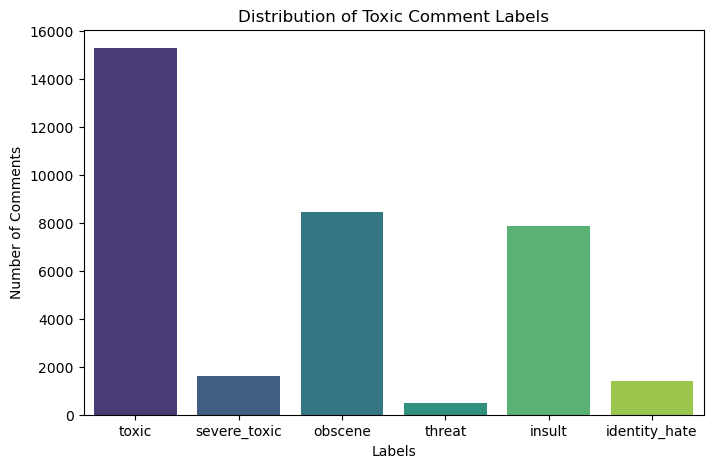

In [ ]:
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
# for bar plot
labels_count = df[labels].sum()
# for label like 0,1,2... to check toxic cmt or not
df['label'] = df[labels].max(axis=1)

plt.figure(figsize = (8,5)) 
sns.barplot(x=labels_count.index, y=labels_count.values, palette='viridis')
plt.title("Distribution of Toxic Comment Labels")
plt.xlabel("Labels")
plt.ylabel("Number of Comments")
plt.show()

df['label'].head(3458)


In [8]:
df[labels].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer() 

def preprocess(text): 
    text = str(text).lower() 
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words] 

    return " ".join(words)

df['comment_text'] = df['comment_text'].apply(preprocess)
#data_test['clean_text'] = data_test['comment_text'].apply(preprocess)

In [10]:
X = df['comment_text']
y = df['label']
df[["comment_text", "label"]]

,comment_text,label
0,explanation edits made username hardcore metal...,0
1,daww match background colour im seemingly stuc...,0
2,hey man im really trying edit war guy constant...,0
3,cant make real suggestion improvement wondered...,0
4,sir hero chance remember page thats,0
...,...,...
159566,second time asking view completely contradicts...,0
159567,ashamed horrible thing put talk page,0
159568,spitzer umm there actual article prostitution ...,0
159569,look like actually put speedy first version de...,0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1,2),min_df=2,max_df=0.9,stop_words='english')
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [13]:
X_train.shape

(127656, 50000)

In [14]:
X_test.shape

(31915, 50000)

In [15]:
model = OneVsRestClassifier(PassiveAggressiveClassifier(max_iter=1000,random_state=42))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy;",accuracy_score(y_test, y_pred))

print("classification_report:",classification_report(y_test,y_pred))

print("Validation Classification Report")
print(classification_report(y_test, y_pred))

Accuracy; 0.9452608491305029
classification_report:               precision    recall  f1-score   support

           0       0.97      0.97      0.97     28671
           1       0.74      0.71      0.72      3244

    accuracy                           0.95     31915
   macro avg       0.85      0.84      0.85     31915
weighted avg       0.94      0.95      0.94     31915

Validation Classification Report
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     28671
           1       0.74      0.71      0.72      3244

    accuracy                           0.95     31915
   macro avg       0.85      0.84      0.85     31915
weighted avg       0.94      0.95      0.94     31915



In [16]:
nb = OneVsRestClassifier(MultinomialNB())
nb.fit(X_train,y_train)
nb_pred = nb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,nb_pred))

Accuracy: 0.9401848660504465


In [17]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [18]:
from xgboost import XGBClassifier 
xgb = OneVsRestClassifier(XGBClassifier())
xgb.fit(X_train,y_train) 
xgb_pred = xgb.predict(X_test) 
accuracy = accuracy_score(y_test, xgb_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, xgb_pred))

Accuracy: 0.9541908193639355
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     28671
           1       0.92      0.60      0.73      3244

    accuracy                           0.95     31915
   macro avg       0.94      0.80      0.85     31915
weighted avg       0.95      0.95      0.95     31915



In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [20]:
svm_model = SVC(kernel='linear')
param_grid = {'C': [0.1, 1, 10]}

In [ ]:
classifier1 = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1
)
classifier1.fit(X_train,y_train)
print("Best GridSearch SVC Params:",classifier1.best_params)
svc_preds = classifier1.predict(X_test)
print("SVC Test Accuracy:", accuracy_score(y_test, svc_preds))
print(classification_report(y_test, svc_preds))

In [ ]:
classifier2 = RandomSearchCV((svm_model),{
    param_distributions=param_grid, 
    n_iter=3, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1, 
    random_state=42
})
classifier2.fit(X_train,y_train)
print("Best RandomSearch SVC Params:", random_svc.best_params_)
svc_preds2 = classifier2.predict(X_test)
print("SVC Test Accuracy:", accuracy_score(y_test, svc_preds2))
print(classification_report(y_test, svc_preds2))

In [ ]:
from sklearn.esemble import BaggingClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
base_learner = [('dt',DecisionTreeClassifier(random_state=42)),
                ('svm_model',SVC(probability=True,kernel='rbf',random_state42)),
                ('lr',LogisricRegression(max_iter=1000))]

meta_learner = DecisionTreeClassifier(random_state=42)

stacking_clf = StackingClassifier(
    estimators = base_learner,
    final_estimator = meta_learner, 
    cv=3
)
stacking_clf.fit(X_train, y_train)
stacking_preds = stacking_clf.predict(X_test)
print("Stacking Test Accuracy:", accuracy_score(y_test, stacking_preds))
print(classification_report(y_test, stacking_preds))

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
boosting_model = AdaBoostClassifier((dt),{
    n_estimators=50,
    random_state=42
})
boosting_model.fit(X_train, y_train)
boosting_preds = boosting_model.fit(X_train, y_train).predict(X_test)
print("AdaBoost Test Accuracy:", accuracy_score(y_test, boosting_preds))
print(classification_report(y_test, boosting_preds))

In [ ]:
base_pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
bagging_model = BaggingClassifier(
    estimator=base_pac, 
    n_estimators=10, 
    random_state=42, 
    n_jobs=-1
)
bagging_model.fit(X_train, y_train)
bagging_preds = bagging_model.predict(X_test)
print("Bagging Test Accuracy:", accuracy_score(y_test, bagging_preds))
print(classification_report(y_test, bagging_preds))

In [ ]:
# Toxic Comment Prediction + Cosine Similarity

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def predict_and_compare(comment):

   
    cleaned = preprocess(comment)
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)[0]

    # Confidence Score (if supported)
    confidence = None
    if hasattr(model, "predict_proba"):
        confidence = model.predict_proba(vector)[0][1]

  
    similarity = cosine_similarity(vector, X)

    # Most Similar Comment
    idx = np.argmax(similarity)

    print("=" * 70)
    print("User Comment:")
    print(comment)

    print("\nPrediction:")
    if prediction == 1:
        print("🟥 TOXIC")
    else:
        print("🟩 NON-TOXIC")

    if confidence is not None:
        print(f"Confidence : {confidence:.2%}")

    print("\nMost Similar Comment in Dataset:")
    print(df.iloc[idx]["comment_text"])

    print(f"\nSimilarity Score : {similarity[0][idx]:.2%}")
    print(f"Dataset Label    : {df.iloc[idx]['label']}")
    print("=" * 70)


while True:

    comment = input("\nEnter a comment (type 'exit' to quit): ")

    if comment.lower() == "exit":
        print("\nThank you for using Toxic Comment Detector!")
        break

    predict_and_compare(comment)